In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from itertools import product
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as mpath
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
import pickle
import itertools
import colorsys
import random
import datetime as dt
import string
from minisom import MiniSom

In [3]:
dataset = xr.open_dataarray('data/Z500Anoms_ERA5.nc')

latSlice = slice(20, 80) #20N, 80N
lonSlice = slice(180, 330) #180W, 30W
dataarray = dataset.sel(lat=latSlice, lon=lonSlice)
dataarray = dataarray.stack(latlon=['lat', 'lon']).values

# Seasonal breakdown of the data
DJF = dataset.time.dt.month.isin([12, 1, 2])
DJF_idxs = np.array(DJF).nonzero()[0]
MAM = dataset.time.dt.month.isin([3, 4, 5])
MAM_idxs = np.array(MAM).nonzero()[0]
JJA = dataset.time.dt.month.isin([6, 7, 8])
JJA_idxs = np.array(JJA).nonzero()[0]
SON = dataset.time.dt.month.isin([9, 10, 11])
SON_idxs = np.array(SON).nonzero()[0]

print(dataarray.shape)

(30660, 9211)


In [4]:
def save_som(som, fileName):
    with open(fileName, 'wb') as outfile:
        pickle.dump(som, outfile)

def load_som(fileName):
    with open(fileName, 'rb') as infile:
        som = pickle.load(infile)
    return som

In [10]:
inputLength = dataarray.shape[1]
n = 5
sigma = 3
learning_rate = .001
neighborhood_function = 'gaussian'
decay_function = 'asymptotic_decay'
random_seed = 28
topology = 'hexagonal'
iteration = 500

# TRAINING
som = MiniSom(n, 1, inputLength, sigma=sigma, learning_rate=learning_rate, 
            neighborhood_function=neighborhood_function, decay_function=decay_function, 
            random_seed=random_seed, topology=topology)
#som.pca_weights_init(dataarray)
som.train(dataarray, iteration, random_order=True, use_epochs=True)

winmap = som.win_map(dataarray, return_indices=True)
w = som._weights
minimum_weight = -np.max(np.abs(w))
maximum_weight = np.max(np.abs(w))

save_som(som, 'nx1_3.p')

In [6]:
som = load_som('nx1.p')

winmap = som.win_map(dataarray, return_indices=True)
w = som._weights
minimum_weight = -np.max(np.abs(w))
maximum_weight = np.max(np.abs(w))

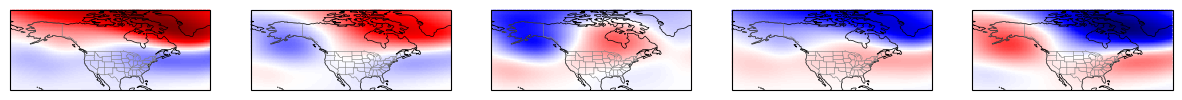

In [11]:
neurons = list(winmap.keys())
lats = dataset.sel(lat=latSlice, lon=lonSlice).lat
lons = dataset.sel(lat=latSlice, lon=lonSlice).lon - 360
lons, lats = np.meshgrid(lons, lats)

# set up the 5 x 1 sub plots
projection = ccrs.PlateCarree()
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 5), subplot_kw={'projection': projection})

for neuron in neurons:
    avgs = np.array(w[neuron[0], neuron[1], :]).reshape((lons.shape[0], lats.shape[1]))
    axs[neuron[0]].pcolor(
        lons, lats, avgs, vmin=minimum_weight, vmax=maximum_weight, cmap='seismic', 
        shading='nearest', transform=ccrs.PlateCarree())
    #axs[neuron[0]].set_title(f"{node_nums[neuron]}", fontsize=16)
    
    # background map features
    axs[neuron[0]].coastlines(resolution='110m', color='k', linewidth=0.5, zorder=10)
    axs[neuron[0]].margins(x=0, y=0)
    axs[neuron[0]].add_feature(
        cfeature.STATES, facecolor='none', edgecolor='grey', linewidth=0.25, zorder=10
    )
    axs[neuron[0]].add_feature(cf.BORDERS, linewidth=0.25, zorder=10, edgecolor='grey')
    axs[neuron[0]].set_extent([-180, -30, 20, 80], crs=projection)